In [2]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.linalg import expm
from qutip import destroy, jmat, tensor, identity, basis, mesolve
import matplotlib as mpl
from matplotlib import cm
import math

from qutip import *
from qutip.piqs import *
from qutip import tensor

import qutip as qt
from qutip import *
from ipywidgets import interact, FloatSlider

from IPython.display import Image
from qutip import (Qobj, about, basis, coherent, coherent_dm, commutator, create, destroy, displace, expect, fock, fock_dm, mesolve, plot_wigner, 
                   ptrace, qeye, sesolve, sigmax, sigmay, sigmaz, tensor)
import sys
import time

np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(linewidth=100)
results=[]
maxint=[]

Defining qubit operators

In [166]:
# define qubit operators 
ket0 = basis(2, 0)
ket1 = basis(2, 1)

X = sigmax()
Y = sigmay()
Z = sigmaz()
H = (1/np.sqrt(2)) * Qobj([[1, 1], [1, -1]]) # Hadamard gate
P = Qobj([[1, 0], [0, 1j]]) # phase gate; avoided notation S to prevent conflict with the squeezing gate S(zeta)

sig_up = ket0 * ket1.dag()   # |e><g|
sig_down = ket1 * ket0.dag() # |g><e|

def r(u, theta): # qubit rotation by angle theta about unit vector u on the Bloch sphere
    return (-0.5j * theta * (u[0] * X + u[1] * Y + u[2] * Z)).expm()

def rz(theta): 
    return r([0, 0, 1], theta)

Qumode Operators

In [167]:
# define qumode operators 
# NOTE: the conditional operators have dimensionality built-in, given by n_qb and n_qm; 
# each single-qumode operator does not, and only acts on one qumode

def R(N, theta): # phase-space rotation (N: qumode dimension, theta: rotation angle)
    return ( -1j * theta * create(N) * destroy(N) ).expm()

def S(N, zeta): # single-mode squeezing (N: qumode dimension, zeta: squeezing parameter)
    return ( 0.5 * (np.conj(zeta) * destroy(N)**2 - zeta * create(N)**2) ).expm()

def JC(N, n_qb, n_qm, b, m, theta, phi): 
    # Jaynes-Cummings (N: qumode dimension, n_qb: number of qubits, n_qm: number of qumodes, 
    # b: qubit index (from 0), m: qumode index (from 0), theta, phi: JC gate parameters)
    qb_list = [qeye(2)] * n_qb # initialize empty list of qubit identities
    qm_list = [qeye(N)] * n_qm # initialize empty list of qumode identities
    qb_list[b] = sig_down
    qm_list[m] = create(N)
    qb_term = tensor(qb_list)
    qm_term = tensor(qm_list)
    term = np.exp(1j * phi) * tensor(qb_term, qm_term)
    exponent = -1j * theta * (term + term.dag())
    return exponent.expm()

def AJC(N, n_qb, n_qm, b, m, theta, phi): 
    # Jaynes-Cummings (N: qumode dimension, n_qb: number of qubits, n_qm: number of qumodes, 
    # b: qubit index (from 0), m: qumode index (from 0), theta, phi: JC gate parameters)
    qb_list = [qeye(2)] * n_qb # initialize empty list of qubit identities
    qm_list = [qeye(N)] * n_qm # initialize empty list of qumode identities
    qb_list[b] = sig_down
    qm_list[m] = destroy(N)
    qb_term = tensor(qb_list)
    qm_term = tensor(qm_list)
    term = np.exp(1j * phi) * tensor(qb_term, qm_term)
    exponent = -1j * theta * (term + term.dag())
    return exponent.expm()

Define miscellaneous functions

In [168]:
# define miscellaneous functions
def Time_Evolution(H, t):
    return (-1j * H * t).expm()

def op_fidelity_unit(U0, U): 
    # computes the fidelity of U with respect to U0; NOTE: U0 and U must be unitary for this measure
    d = U.shape[0]
    return np.abs( (U0.dag() * U).tr() )**2 / d**2

Unitary Operators

In [169]:
# exciton-only term of Hamiltonian for decomposed U(t)

def U_ex_decomp(dt): # time evolution operator from native gate decomposition for one Trotter step
    oper_list = I_ex_list.copy() 
    for n in range(n_ex): 
        # oper_list[n] = np.exp(-0.5j * w_ex_list[n] * dt) * rz(w_ex_list[n] * dt) # phase factor included 
        oper_list[n] = rz(w_ex_list[n] * dt) # phase factor not included
    return tensor(oper_list)

# photon-only term of Hamiltonian for decomposed U(t)

def U_phot_decomp(dt): # time evolution operator from native gate decomposition for one Trotter step
    oper_list = I_phot_list.copy() 
    for q in range(n_phot): 
        oper_list[q] = R(N, w_phot_list[q] * dt)
    return tensor(oper_list)


# exciton-photon interaction term of Hamiltonian for decomposed U(t)

def U_ex_phot_decomp_step(dt):
    oper_list = []
    for n in range(n_ex): 
        for q in range(n_phot): 
            theta = np.abs(np.conj(h_list[n][q])) * dt
            phi = np.angle(np.conj(h_list[n][q]))
            oper_list.append(JC(N, n_ex, n_phot, n, q, theta, phi)) 
            # here the full dimensionality is not built in; only exciton and photon dimension are included
    oper_list.reverse()
    return math.prod(oper_list)

def U_ex_phot_decomp(t, n_trot): # Trotterized decomposition
    return U_ex_phot_decomp_step(t/n_trot) ** n_trot


# decomposition for full Hamiltonian

def U_ex_phot_full_decomp_stepJC(dt):
    oper_list = []
    for n in range(n_ex): 
        for q in range(n_phot): 
            theta = np.abs(np.conj(h_list[n][q])) * dt
            phi = np.angle(np.conj(h_list[n][q]))
            oper_list.append(JC(N, n_qb, n_qm, n, q, theta, phi)) # here the full dimensionality is built in
    oper_list.reverse()
    return math.prod(oper_list)

def U_ex_phot_full_decomp_stepAJC(dt):
    oper_list = []
    for n in range(n_ex): 
        for q in range(n_phot): 
            theta = np.abs(np.conj(h_list[n][q])) * dt
            phi = np.angle(np.conj(h_list[n][q]))
            oper_list.append(AJC(N, n_qb, n_qm, n, q, theta, phi)) # here the full dimensionality is built in
    oper_list.reverse()
    return math.prod(oper_list)

def U_tot_decomp_step(dt): 
    return U_ex_phot_full_decomp_stepJC(dt) * tensor(I_ex, U_phot_decomp(dt)) * tensor(U_ex_decomp(dt), I_phot) 
    #didn't include the AJC part here

    #return U_ex_phot_full_decomp_stepAJC(dt)*U_ex_phot_full_decomp_stepJC(dt) * 
    #    tensor(I_ex, U_phot_decomp(dt)) * tensor(U_ex_decomp(dt), I_phot) #didn't include the AJC part here

def U_tot_decomp(t, n_trot): # Trotterized decomposition 
    return U_tot_decomp_step(t/n_trot) ** n_trot

# Open Channel Cavity Decay
def U_open_channel_cavity_decay(dt):
    ops = []
    for a in range(n_anc):
        for q in range(n_phot):
            theta = np.sqrt(kappa * dt) 
            phi = -np.pi/2
            ops.append(JCA(N, n_anc, n_qm, a, q, theta, phi))
    ops.reverse()
    return math.prod(ops)

# Jaynes-Cumming Ancilla
def JCA(N, n_anc, n_qm, a, m, theta, phi):
    # Order is (photon, ancilla)
    anc_list = [qeye(2)] * n_anc
    qm_list = [qeye(N)] * n_qm

    anc_list[a] = sig_down
    qm_list[m] = create(N)

    anc_term = tensor(anc_list)
    qm_term = tensor(qm_list)

    term = np.exp(1j * phi) * tensor(qm_term, anc_term)
    return (-1j * theta * (term + term.dag())).expm()

In [170]:
# Other general functions
def build_operators1(n_ex, n_phot, N):
    num_ex_local_list = []
    for n in range(n_ex):
        oper_list = I_ex_list.copy()
        oper_list[n] = sig_up * sig_down
        num_ex_local_list.append(tensor(oper_list))
    num_ex_op = sum(num_ex_local_list)

    J_plus_list = []
    J_minus_list = []
    for n in range(n_ex):
        op_list = I_ex_list.copy()
        op_list[n] = sig_up
        J_plus_list.append(tensor(op_list))
        op_list = I_ex_list.copy()
        op_list[n] = sig_down
        J_minus_list.append(tensor(op_list))
    J_plus = sum(J_plus_list)
    J_minus = sum(J_minus_list)
    JpJm = J_plus * J_minus

    photon_num_list = []
    for n in range(n_phot):
        ops = I_phot_list.copy()
        ops[n] = create(N) * destroy(N)
        photon_num_list.append(tensor(ops))
    phot_num_op = sum(photon_num_list)
    

    return num_ex_op, JpJm, phot_num_op, num_ex_local_list, J_plus_list, J_minus_list, photon_num_list

# Appearance and disappearance of SF

Parameters and Initializations

In [128]:
# define parameters for the system
# units: hbar = 1; times are in ps; frequencies are in THz

n_ex = 4
n_phot = 3
n_qb = n_ex
n_qm = n_phot
N = 5 # Fock truncation

n_tPts = 126
t_list = np.linspace(0, 1.25, 126) # (Start time, Finish time, number of points)
dt = t_list[1] - t_list[0]
w_ex_list = [1.0] * n_ex # [0 * np.pi] * n_ex
I_ex_list = [qeye(2)] * n_ex
I_ex = tensor(I_ex_list)


if n_phot != 0:
    w_phot_list = [-4, 1, 6]
    I_phot_list = [qeye(N)] * n_phot
    I_phot = tensor(I_phot_list)


if n_phot != 0:
    # Exciton-photon coupling constants with very small phase differences
    h_abs = 1.0
    rng = np.random.default_rng(seed=123)
    base_phase = 0 #rng.uniform(0, 2 * np.pi)
    phase_spread = 6.0  # radians; smaller value means phases are closer
    small_phase_offsets = rng.uniform(-phase_spread / 2, phase_spread / 2, size=(n_ex, n_phot))
    phases = base_phase + small_phase_offsets
    h_list = h_abs * np.exp(1j * phases)
    I_ex_phot_list = I_ex_list + I_phot_list
    I_tot_list = I_ex_list + I_phot_list
else:
    I_tot_list = I_ex_phon_list


n_ex_string = str(n_ex)
w_ex_string = f"{w_ex_list[0]:.2f}"
w_phot_string = f"{w_phot_list[0]:.2f}"
h_string = f"{np.abs(h_list[0][0]):.2f}"
N_trunc_string = str(N)
dt_string = f"{dt:.3f}"


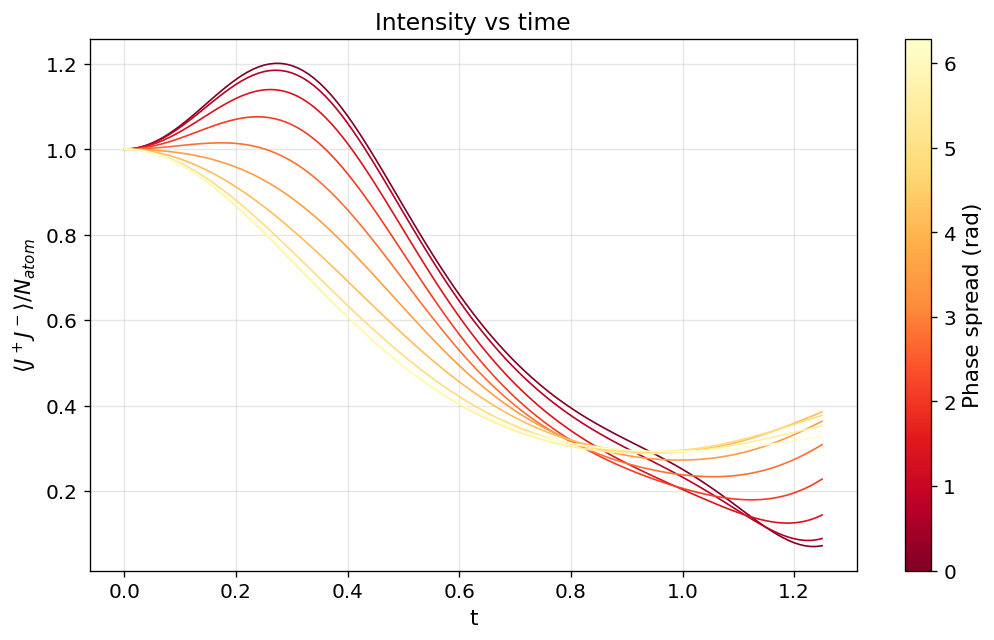

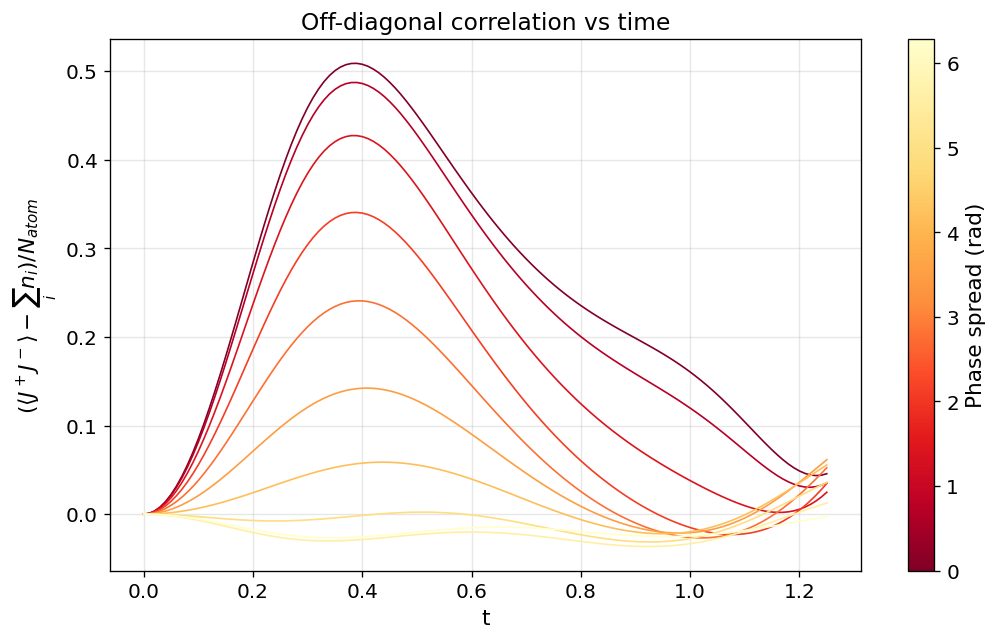

In [129]:
use_decomp = True

phase_spread_values = np.linspace(0, 2 * np.pi, 10)


def truncated_cmap(cmap_name="viridis", low=0.0, high=0.38):
    base = plt.colormaps[cmap_name]
    return mcolors.LinearSegmentedColormap.from_list(
        f"{cmap_name}_trunc", base(np.linspace(low, high, 256))
    )


def build_h_list(phase_spread):
    rng = np.random.default_rng(seed=123)
    base_phase = 0
    small_phase_offsets = rng.uniform(-phase_spread / 2, phase_spread / 2, size=(n_ex, n_phot))
    phases = base_phase + small_phase_offsets
    return h_abs * np.exp(1j * phases)


def build_initial_state():
    ket_i_ex = tensor(ket0, tensor([ket0] * (n_ex - 1)))
    ket_i_phot = tensor([fock(N, 0)] * n_phot)
    return tensor(ket_i_ex, ket_i_phot)


def build_operators():
    num_ex_local_list = []
    for n in range(n_ex):
        oper_list = I_ex_list.copy()
        oper_list[n] = sig_up * sig_down
        num_ex_local_list.append(tensor(oper_list))
    num_ex_op = sum(num_ex_local_list)

    J_plus_list = []
    J_minus_list = []
    for n in range(n_ex):
        op_list = I_ex_list.copy()
        op_list[n] = sig_up
        J_plus_list.append(tensor(op_list))
        op_list = I_ex_list.copy()
        op_list[n] = sig_down
        J_minus_list.append(tensor(op_list))
    J_plus = sum(J_plus_list)
    J_minus = sum(J_minus_list)
    JpJm = J_plus * J_minus

    return num_ex_op, JpJm


def evolve(U_step, num_ex_op, JpJm):
    num_ex_expect_list = [0] * n_tPts
    JpJm_expect_list = [0] * n_tPts
    ket_current = build_initial_state()
    for t_index in range(n_tPts):
        num_ex_expect_list[t_index] = (
            ket_current.dag() * tensor(num_ex_op, I_phot) * ket_current
        ).real
        JpJm_expect_list[t_index] = (
            ket_current.dag() * tensor(JpJm, I_phot) * ket_current
        ).real
        if t_index != n_tPts - 1:
            ket_current = U_step * ket_current
    return num_ex_expect_list, JpJm_expect_list


def run_phase_spread_sweep(phase_spread_values):
    global h_list
    num_ex_op, JpJm = build_operators()
    total_results = []
    offdiag_results = []
    for phase_spread in phase_spread_values:
        h_list = build_h_list(phase_spread)
        U_step = U_tot_decomp_step(dt) if use_decomp else U_tot_exact(dt)
        num_ex_expect_list, JpJm_expect_list = evolve(U_step, num_ex_op, JpJm)

        offdiag_expect_list = [
            JpJm_expect_list[t] - num_ex_expect_list[t] for t in range(n_tPts)
        ]

        total_results.append([i / n_ex for i in JpJm_expect_list])
        offdiag_results.append([i / n_ex for i in offdiag_expect_list])
    return total_results, offdiag_results


def _plot_sweep(results, phase_spread_values, ylabel, title, save_path, cmap):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    norm = plt.Normalize(vmin=phase_spread_values.min(), vmax=phase_spread_values.max())

    for phase_spread, curve in zip(phase_spread_values, results):
        ax.plot(t_list, curve, color=cmap(norm(phase_spread)), linewidth=1.0)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Phase spread (rad)")

    ax.set_xlabel("t")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    # Save directly as a vector PDF graphic
    fig.savefig(save_path, format="pdf", bbox_inches="tight")
    #fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig


def plot_phase_spread_sweep(total_results, phase_spread_values, cmap, save_path="phase_spread_sweep.pdf"):
    return _plot_sweep(
        total_results, phase_spread_values,
        ylabel=r"$\langle J^+ J^- \rangle/N_{atom}$",
        title=f"Intensity vs time",
        save_path=save_path,
        cmap=cmap,
        # Phase spread from 0 to 2Pi for 4 TLS
    )


def plot_offdiag_phase_spread_sweep(offdiag_results, phase_spread_values, cmap, save_path="phase_spread_offdiag_sweep.pdf"):
    return _plot_sweep(
        offdiag_results, phase_spread_values,
        ylabel=r"$(\langle J^+ J^- \rangle - \sum_i n_i)/N_{atom}$",
        title=f"Off-diagonal correlation vs time",
        save_path=save_path,
        cmap=cmap,
        # Phase spread from 0 to 2Pi for 4 TLS
    )


cmap = truncated_cmap("YlOrRd", 1.0, 0.0)
cmap1 = truncated_cmap("YlOrRd", 1.0, 0.0)
total_results, offdiag_results = run_phase_spread_sweep(phase_spread_values)
fig_total = plot_phase_spread_sweep(total_results, phase_spread_values, cmap)
fig_offdiag = plot_offdiag_phase_spread_sweep(offdiag_results, phase_spread_values, cmap1)
plt.show()

# Open Cavity Decay

In [130]:
n_ex = 3
n_phot = 1
n_anc = 1
n_qb = n_ex
n_qm = n_phot
N = 8               # Fock truncation

n_tPts = 2001
t_list = np.linspace(0, 20, 2001) # (Start time, Finish time, number of points)
dt = t_list[1] - t_list[0]
w_ex_list = [0.05] * n_ex # [0 * np.pi] * n_ex
w_phot_list = [1.0] * n_phot
h_list = 0.5 * np.ones((n_ex, n_phot), dtype=np.complex128)#/np.sqrt(n_ex)
kappa = 0.2

I_ex_list = [qeye(2)] * n_ex
I_ex = tensor(I_ex_list)
I_phot_list = [qeye(N)] * n_phot
I_phot = tensor(I_phot_list)
I_anc_list = [qeye(2)] * n_anc
I_anc = tensor(I_anc_list)

# Convention: |e> = |0>, |g> = |1>
ket_i_ex = tensor(ket0, tensor([ket0] * (n_ex - 1)))
ket_i_phot = tensor([fock(N, 0)] * n_phot)
ket_i_anc = tensor([ket1] * n_anc)
ket_i_full = tensor(ket_i_ex, ket_i_phot, ket_i_anc)

# Density matrix because ancilla is reset each step
rho_current = ket_i_full * ket_i_full.dag()
rho_anc_reset = ket_i_anc * ket_i_anc.dag()


Time evolution

In [131]:
def U_tot_decomp_step(dt):
    return (
        tensor(I_ex, U_open_channel_cavity_decay(dt))
        * tensor(U_ex_phot_full_decomp_stepAJC(dt), I_anc)
        * tensor(U_ex_phot_full_decomp_stepJC(dt), I_anc)
        * tensor(I_ex, U_phot_decomp(dt), I_anc)
        * tensor(U_ex_decomp(dt), I_phot, I_anc)
    )


num_ex_op, JpJm, phot_num_op, num_ex_local_list, J_plus_list, J_minus_list, photon_num_list = build_operators1(
    n_ex, n_phot, N)
num_ex_full = tensor(num_ex_op, I_phot, I_anc)
num_ex_local_full = [tensor(op, I_phot, I_anc) for op in num_ex_local_list]
phot_num_full = tensor(I_ex, phot_num_op, I_anc)
phot_num_local_full = [tensor(I_ex, op, I_anc) for op in photon_num_list]


corr_ops = {}
for i in range(n_ex):
    for j in range(n_ex):
        ops = I_ex_list.copy()
        ops[i] = sig_up
        ops[j] = sig_down
        corr_ops[(i, j)] = tensor(ops)
for n in range(n_ex):
    ops = I_ex_list.copy()
    ops[n] = sig_up
    J_plus_list.append(tensor(ops))
    ops = I_ex_list.copy()
    ops[n] = sig_down
    J_minus_list.append(tensor(ops))


full_corr_ops = {key: tensor(op, I_phot, I_anc) for key, op in corr_ops.items()}
full_JpJm = tensor(JpJm, I_phot, I_anc)
num_ex_expect_list = np.zeros(n_tPts)
num_ex_local_expect_list = np.zeros((n_ex, n_tPts))
num_phot_expect_list = np.zeros(n_tPts)
num_phot_local_expect_list = np.zeros((n_phot, n_tPts))
corr_expect = {(i, j): np.zeros(n_tPts, dtype=np.complex128) for (i, j) in corr_ops}
sum_corr_check = np.zeros(n_tPts)
JpJm_expect_list = np.zeros(n_tPts)
U_step = U_tot_decomp_step(dt)
keep_sys = list(range(n_ex + n_phot))  # keep excitons + photons, trace out ancilla


for t_index in range(n_tPts):
    num_ex_expect_list[t_index] = np.real(expect(num_ex_full, rho_current))
    num_ex_local_expect_list[:, t_index] = np.real(expect(num_ex_local_full, rho_current))
    num_phot_expect_list[t_index] = np.real(expect(phot_num_full, rho_current))
    num_phot_local_expect_list[:, t_index] = np.real(expect(phot_num_local_full, rho_current))
    total_corr = 0.0 + 0.0j
    for (i, j), op in full_corr_ops.items():
        val = expect(op, rho_current)
        corr_expect[(i, j)][t_index] = val
        total_corr += val
    sum_corr_check[t_index] = np.real(total_corr)
    JpJm_expect_list[t_index] = np.real(expect(full_JpJm, rho_current))
    if t_index != n_tPts - 1:
        rho_current = U_step * rho_current * U_step.dag()
        rho_sys = ptrace(rho_current, keep_sys)
        rho_current = tensor(rho_sys, rho_anc_reset)
rho_without_anc = ptrace(rho_current, keep_sys)
diff = np.max(np.abs(JpJm_expect_list - sum_corr_check))
print(f"Max difference (J+J- vs sum): {diff:.3e}")


Max difference (J+J- vs sum): 3.000e+00


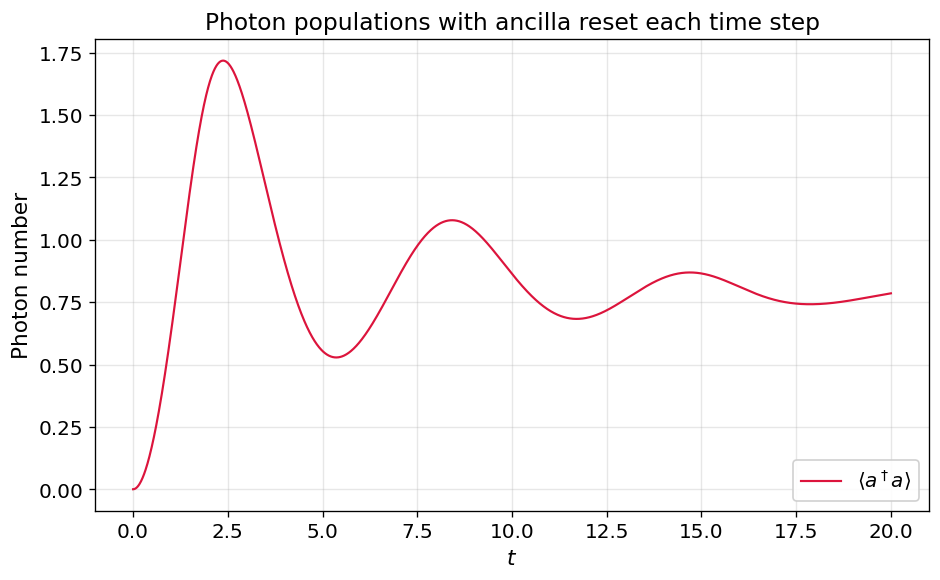

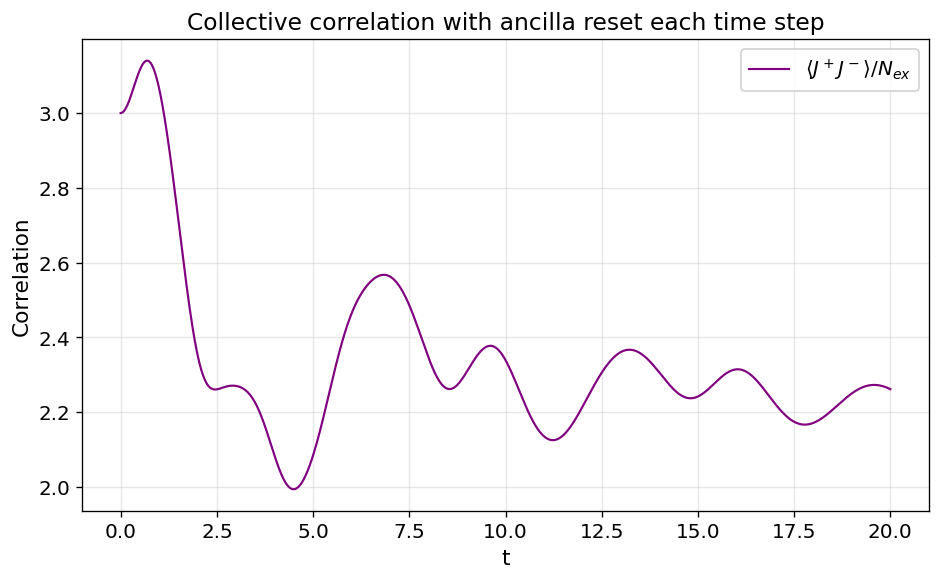

In [132]:
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
})

fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(t_list, num_phot_expect_list, label=r"$\langle a^\dagger a \rangle$",
         color="crimson", linewidth=1.3)
ax1.set_xlabel(r"$t$")
ax1.set_ylabel("Photon number")
ax1.set_title("Photon populations with ancilla reset each time step")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
fig1.savefig("open_cavity_photon_number.png", dpi=300, bbox_inches="tight")

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(t_list, JpJm_expect_list, label=r"$\langle J^+J^- \rangle / N_{ex}$",
         color="purple", linewidth=1.3)
# ax2.plot(t_list, sum_corr_check / n_ex, "--", label="explicit sum / $N_{ex}$", color="black")
ax2.set_xlabel("t")
ax2.set_ylabel("Correlation")
ax2.set_title("Collective correlation with ancilla reset each time step")
ax2.legend(loc="best")
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig("open_cavity_correlation.png", dpi=300, bbox_inches="tight")

plt.show()

/opt/anaconda3/envs/pennylane-env/lib/python3.10/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


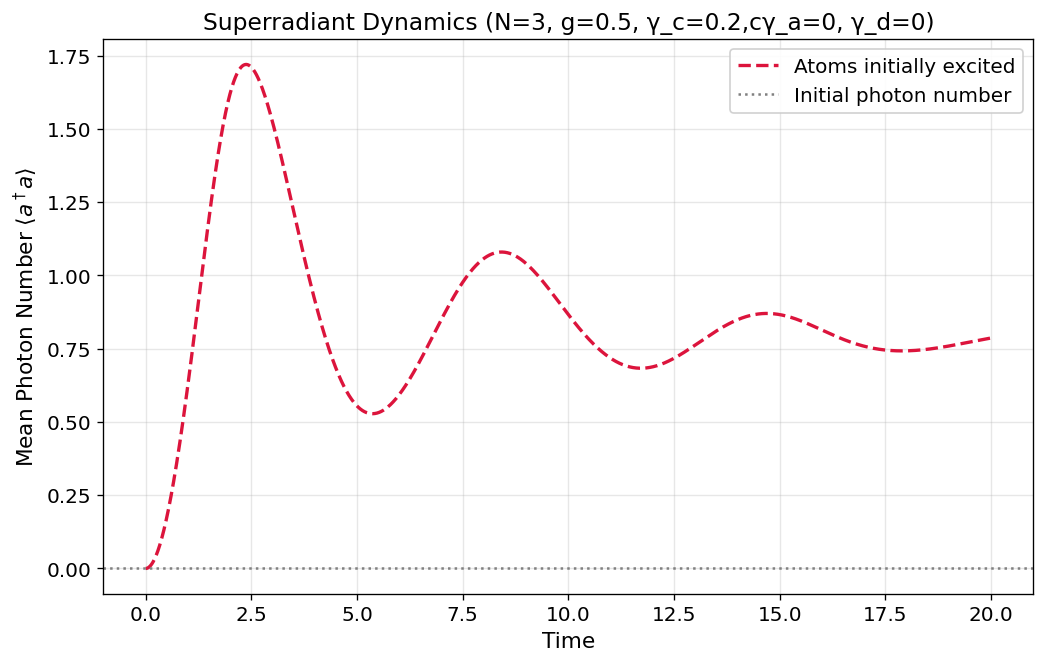

In [133]:
#Open Dicke model

N = 3            # Number of atoms
M = 8               # Cavity cutoff
omega_c = 1.0    #1.0    # Cavity frequency
omega_a = 0.05   #1.0     # Atomic frequency
g = 0.5             # Coupling strength (above g_c for superradiance)
gamma_c = 0.2   # Cavity decay rate
gamma_a = 0#0.1    # Atomic decay rate
gamma_d = 0#0.01   # Atomic dephasing
times = np.linspace(0, 20, 2000) #np.linspace(0, 40, 1000)  # Time evolution


# Cavity
a = destroy(M)
n_op = a.dag() * a

# Collective spin
j = N / 2.0
Jz = jmat(j, 'z')
Jp = jmat(j, '+')
Jm = jmat(j, '-')

# Hamiltonian
H = (omega_c * tensor(n_op, identity(int(2*j+1))) +
     omega_a * tensor(identity(M), Jz) +
     g * tensor(a + a.dag(), Jp + Jm))

#g * tensor(a + a.dag(), Jp + Jm))
# Collapse Operators (Dissipation)

c_ops = []

# Cavity decay
c_ops.append(np.sqrt(gamma_c) * tensor(a, identity(int(2*j+1))))

# Atomic spontaneous emission
c_ops.append(np.sqrt(gamma_a) * tensor(identity(M), Jm))

# dephasing (missing in your code)
c_ops.append(np.sqrt(gamma_d) * tensor(identity(M), Jz))


# Cavity starts in Fock state |n>
initial_fock = 0

# Ground state atoms |J, -J>
psi0_ground = tensor(basis(M, initial_fock), basis(int(2*j+1), int(2*j)))

# Fully excited atoms |J, +J>
psi0_excited = tensor(basis(M, initial_fock), basis(int(2*j+1), 0))

# Master equation
result_ground = mesolve(H, psi0_ground, times, c_ops, [tensor(n_op, identity(int(2*j+1)))])
result_excited = mesolve(H, psi0_excited, times, c_ops, [tensor(n_op, identity(int(2*j+1)))])


plt.figure(figsize=(10,6))
#plt.plot(times, result_ground.expect[0], label='Atoms initially in ground state', color='royalblue', linewidth=2)
plt.plot(times, result_excited.expect[0], label='Atoms initially excited', color='crimson', linestyle='--', linewidth=2)
plt.axhline(y=initial_fock, color='gray', linestyle=':', label='Initial photon number')
plt.xlabel('Time')
plt.ylabel(r'Mean Photon Number $\langle a^\dagger a \rangle$')
plt.title(f'Superradiant Dynamics (N={N}, g={g}, γ_c={gamma_c},cγ_a={gamma_a}, γ_d={gamma_d})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

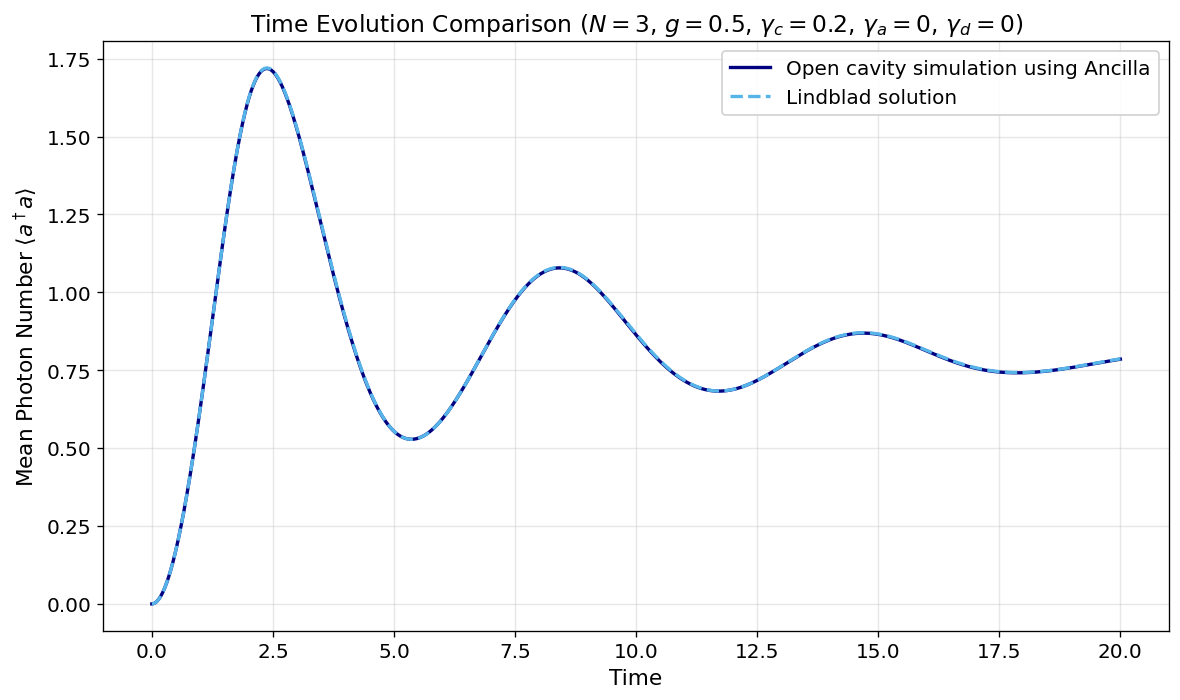

In [134]:
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_list, num_phot_expect_list, label="Open cavity simulation using Ancilla",
         color="navy", linewidth=2)
ax.plot(times, result_excited.expect[0], label="Lindblad solution",
         color="#56B4E9", linestyle="--", linewidth=2)

ax.set_xlabel("Time")
ax.set_ylabel(r"Mean Photon Number $\langle a^\dagger a \rangle$")
ax.set_title(
    rf"Time Evolution Comparison ($N={N}$, $g={g}$, $\gamma_c={gamma_c}$, "
    rf"$\gamma_a={gamma_a}$, $\gamma_d={gamma_d}$)"
)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("photon_number_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Free Space Dicke Model

n_ex=2, N_list=[6, 6, 6]: max diff (J+J- vs sum) = 4.441e-16
n_ex=3, N_list=[6, 6, 6]: max diff (J+J- vs sum) = 1.776e-15
n_ex=4, N_list=[6, 6, 6]: max diff (J+J- vs sum) = 5.329e-15
n_ex=5, N_list=[6, 6, 6]: max diff (J+J- vs sum) = 8.882e-15


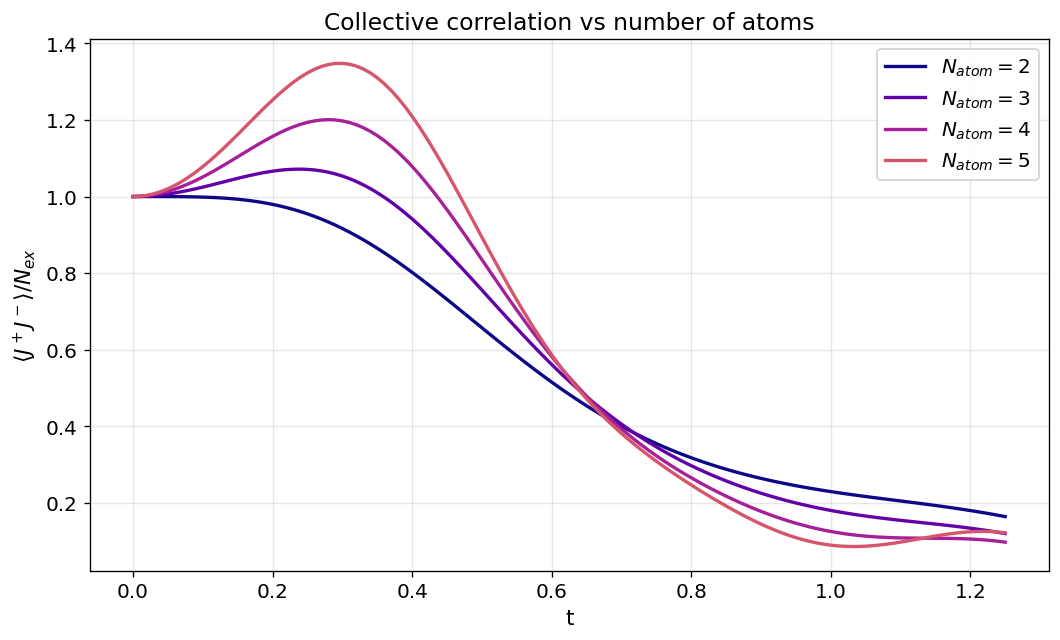

In [3]:
ket0 = basis(2, 0)
ket1 = basis(2, 1)
X = sigmax()
Y = sigmay()
Z = sigmaz()
sig_up = ket0 * ket1.dag()      # |e><g|
sig_down = ket1 * ket0.dag()    # |g><e|


def r(u, theta):
    return (-0.5j * theta * (u[0] * X + u[1] * Y + u[2] * Z)).expm()


def rz(theta):
    return r([0, 0, 1], theta)


def zero_op(dim):
    return Qobj(np.zeros((dim, dim), dtype=np.complex128))


# N_list[q] = 1 freezes mode q in vacuum.
def make_N_list(n_phot, default_N=2, overrides=None):
    N_list = [default_N] * n_phot
    if overrides:
        for idx, N in overrides.items():
            N_list[idx] = N
    return N_list


def build_system(n_ex, n_phot, N_list, w_ex_list, w_phot_list, h_abs):
    n_qb = n_ex
    I_ex_list = [qeye(2) for _ in range(n_ex)]
    I_ex = tensor(I_ex_list)
    I_phot_list = [qeye(N_list[q]) for q in range(n_phot)]
    I_phot = tensor(I_phot_list)
    I_full = tensor(I_ex_list + I_phot_list)
    h_list = h_abs * np.ones((n_ex, n_phot), dtype=np.complex128)

    def mode_op(op, target, dims):
        ops = [qeye(d) for d in dims]
        ops[target] = op
        return tensor(ops)

    def safe_destroy(dim):
        return zero_op(1) if dim == 1 else destroy(dim)

    def safe_create(dim):
        return zero_op(1) if dim == 1 else create(dim)

    def safe_number(dim):
        if dim == 1:
            return zero_op(1)
        a = destroy(dim)
        return a.dag() * a

    def R_local(dim, theta):
        if dim == 1:
            return qeye(1)
        a = destroy(dim)
        return (-1j * theta * a.dag() * a).expm()

    def photon_create_full(target, dims):
        return mode_op(safe_create(dims[target]), target, dims)

    def full_identity(dims, n_qb):
        return tensor([qeye(2) for _ in range(n_qb)] + [qeye(d) for d in dims])

    def JC_multi(dims, n_qb, b, m, theta, phi):
        if dims[m] == 1:
            return full_identity(dims, n_qb)
        qb_list = [qeye(2) for _ in range(n_qb)]
        qb_list[b] = sig_down
        qb_term = tensor(qb_list)
        qm_term = photon_create_full(m, dims)
        term = np.exp(1j * phi) * tensor(qb_term, qm_term)
        return (-1j * theta * (term + term.dag())).expm()

    def U_ex_decomp(dt_step):
        ops = I_ex_list.copy()
        for n in range(n_ex):
            ops[n] = rz(w_ex_list[n] * dt_step)
        return tensor(ops)

    def U_phot_decomp(dt_step):
        ops = I_phot_list.copy()
        for q in range(n_phot):
            ops[q] = R_local(N_list[q], w_phot_list[q] * dt_step)
        return tensor(ops)

    def qobj_prod(ops, identity):
        out = identity
        for op in ops:
            out = op * out
        return out

    def U_ex_phot_full_decomp_stepJC(dt_step):
        ops = []
        for n in range(n_ex):
            for q in range(n_phot):
                theta = np.abs(np.conj(h_list[n][q])) * dt_step
                phi = np.angle(np.conj(h_list[n][q]))
                ops.append(JC_multi(N_list, n_qb, n, q, theta, phi))
        ops.reverse()
        return qobj_prod(ops, I_full)

    def U_tot_decomp_step(dt_step):
        # JC-only: AJC (counter-rotating) term intentionally omitted.
        return (
            U_ex_phot_full_decomp_stepJC(dt_step)
            * tensor(I_ex, U_phot_decomp(dt_step))
            * tensor(U_ex_decomp(dt_step), I_phot)
        )

    ket_i_ex = tensor(ket0, tensor([ket0] * (n_ex - 1)))
    ket_i_phot = tensor([fock(N_list[q], 0) for q in range(n_phot)])
    ket_i = tensor(ket_i_ex, ket_i_phot)

    corr_ops = {}
    for i in range(n_ex):
        for j in range(n_ex):
            ops = I_ex_list.copy()
            if i == j:
                ops[i] = sig_up * sig_down
            else:
                ops[i] = sig_up
                ops[j] = sig_down
            corr_ops[(i, j)] = tensor(ops)

    J_plus_list, J_minus_list = [], []
    for n in range(n_ex):
        ops = I_ex_list.copy()
        ops[n] = sig_up
        J_plus_list.append(tensor(ops))
        ops = I_ex_list.copy()
        ops[n] = sig_down
        J_minus_list.append(tensor(ops))
    J_plus = sum(J_plus_list)
    J_minus = sum(J_minus_list)
    JpJm = J_plus * J_minus

    return {
        "ket_i": ket_i,
        "U_tot_decomp_step": U_tot_decomp_step,
        "full_corr_ops": {key: tensor(op, I_phot) for key, op in corr_ops.items()},
        "full_JpJm": tensor(JpJm, I_phot),
    }


def run_correlation(n_ex, n_phot, N_list, w_ex_list, w_phot_list, h_abs, t_list, dt):
    n_tPts = len(t_list)
    sys = build_system(n_ex, n_phot, N_list, w_ex_list, w_phot_list, h_abs)
    U_step = sys["U_tot_decomp_step"](dt)
    A_tot = sys["full_JpJm"]

    JpJm_expect_list = np.zeros(n_tPts)
    sum_corr_check = np.zeros(n_tPts)

    ket_current = sys["ket_i"]
    for t_index in range(n_tPts):
        total_corr = 0.0 + 0.0j
        for op in sys["full_corr_ops"].values():
            total_corr += expect(op, ket_current)
        sum_corr_check[t_index] = np.real(total_corr)
        JpJm_expect_list[t_index] = np.real(expect(A_tot, ket_current))
        if t_index != n_tPts - 1:
            ket_current = U_step * ket_current

    diff = np.max(np.abs(JpJm_expect_list - sum_corr_check))
    return JpJm_expect_list, diff


if __name__ == "__main__":
    n_ex_values = [2, 3, 4, 5]
    n_phot = 3
    w_phot_list = [-4, 0.0, 4]
    h_abs = 0.96

    t_max = 1.25
    n_tPts = 126
    t_list = np.linspace(0.0, t_max, n_tPts)
    dt = t_list[1] - t_list[0]

    # Different truncation per mode and per n_ex.
    # Resonant mode (index 1, omega=0) holds the most photons -> highest cutoff,
    N_list_map = {
        2: [6, 6, 6], #[2, 3, 3, 3, 2],
        3: [6, 6, 6],#[2, 3, 4, 3, 2],
        4: [6, 6, 6],#[2, 3, 5, 3, 2],
        5: [6, 6, 6],#[2, 3, 6, 3, 2],
        #6: [2, 3, 7, 3, 2],
        #7: [3, 10, 3],
    }

    results_corr = []
    for n_ex in n_ex_values:
        N_list = N_list_map[n_ex]
        w_ex_list = [0.0] * n_ex
        JpJm_expect_list, diff = run_correlation(
            n_ex, n_phot, N_list, w_ex_list, w_phot_list, h_abs, t_list, dt
        )
        print(f"n_ex={n_ex}, N_list={N_list}: max diff (J+J- vs sum) = {diff:.3e}")
        results_corr.append(JpJm_expect_list / n_ex)

   
    plt.rcParams.update({
        "figure.dpi": 120,
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "legend.frameon": True,
        "legend.framealpha": 0.9,
    })

    colors = plt.cm.plasma(np.linspace(0, 0.55, len(n_ex_values)))

    fig, ax = plt.subplots(figsize=(9, 5.5))
    for n_ex, curve, color in zip(n_ex_values, results_corr, colors):
        ax.plot(t_list, curve, color=color, linewidth=2, label=rf"$N_{{atom}}={n_ex}$")
    ax.set_xlabel("t")
    ax.set_ylabel(r"$\langle J^+ J^- \rangle / N_{ex}$")
    ax.set_title("Collective correlation vs number of atoms")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig("n_ex_correlation_sweep.pdf", bbox_inches="tight")
    plt.show()